<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Lab06_Regression_(with%20Answer%20Key).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6 — Build It, Judge It, Tame It

**Machine Learning · Week 6 · Linear & Logistic Models**

| | |
|---|---|
| **Time budget** | ~2 hours (in-lab) |
| **Learning objectives** | 1. Fit and interpret linear regression; implement gradient descent from scratch — 2. Report and interpret the full regression metric family — 3. Diagnose model problems from residual plots — 4. Apply and compare L1/L2 regularization; build a calibrated logistic classifier |
| **Datasets** | Bangkok condo prices (synthetic, built here) · SMS Spam Collection (real, 5,572 messages) |

> **Today you look under the hood.** Every model so far has been `.fit()` — a black box that "trains." In Part 2 you will write the training loop yourself, in about fifteen lines, and watch the cost fall. After that, "the model trains" is never mysterious again.

⚠️ **First:** File → Save a copy in Drive, rename to `Lab6_<your_student_id>`.

---
## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, precision_score, recall_score,
                             classification_report)

RNG_SEED = 42
np.random.seed(RNG_SEED)
print("Setup complete ✔")

Setup complete ✔


---
## Part 1 · A dataset you can reason about

We'll build a Bangkok condo dataset with a known structure, so you can check whether the model recovers what we put in. Four features: floor area, bedrooms, building age, and walking distance to the nearest BTS station.

*(Building it ourselves also means no download, and identical results for everyone.)*

In [3]:
rng = np.random.default_rng(11)
n = 500

size   = rng.uniform(25, 160, n)                                   # m²
rooms  = np.clip(np.round(size/38 + rng.normal(0, .5, n)), 1, 5)    # bedrooms
age    = rng.uniform(0, 40, n)                                      # years
bts_km = np.abs(rng.normal(1.6, 1.1, n)) + 0.1                       # km to BTS

# the TRUE relationship we are hiding in the data (millions of baht)
price = (0.052*size + 0.35*rooms - 0.028*age - 0.42*bts_km + 2.4
         + rng.normal(0, 0.45, n))

# six genuine luxury sales — real, not typos (remember Week 2's mansions)
lux = rng.choice(n, 6, replace=False)
price[lux] *= rng.uniform(2.6, 3.4, 6)

FEATURES = ["size_m2", "bedrooms", "age_years", "bts_km"]
X = np.column_stack([size, rooms, age, bts_km])
condo = pd.DataFrame(X, columns=FEATURES).assign(price_mB=price)

X_tr, X_te, y_tr, y_te = train_test_split(X, price, test_size=0.25, random_state=RNG_SEED)
print(condo.describe().round(2).to_string())

       size_m2  bedrooms  age_years  bts_km  price_mB
count   500.00    500.00     500.00  500.00    500.00
mean     90.02      2.43      19.87    1.76      6.82
std      39.05      1.11      11.57    0.99      3.07
min      25.29      1.00       0.02    0.11      1.44
25%      55.85      1.00      10.00    1.03      4.66
50%      88.01      2.00      19.03    1.71      6.60
75%     124.28      3.00      29.89    2.39      8.74
max     159.84      5.00      39.85    5.04     32.20


In [4]:
lin = LinearRegression().fit(X_tr, y_tr)

print("What the model learned:\n")
for name, coef in zip(FEATURES, lin.coef_):
    print(f"  {name:12s} {coef:+.4f}")
print(f"  {'intercept':12s} {lin.intercept_:+.4f}")

print("\nRead as sentences:")
print(f"  • each extra m² adds about {lin.coef_[0]*1_000_000:,.0f} baht")
print(f"  • each extra bedroom adds about {lin.coef_[1]*1_000_000:,.0f} baht")
print(f"  • each year of age costs about {abs(lin.coef_[2])*1_000_000:,.0f} baht")
print(f"  • each km further from the BTS costs about {abs(lin.coef_[3])*1_000_000:,.0f} baht")

What the model learned:

  size_m2      +0.0486
  bedrooms     +0.6352
  age_years    -0.0184
  bts_km       -0.5954
  intercept    +2.3372

Read as sentences:
  • each extra m² adds about 48,552 baht
  • each extra bedroom adds about 635,160 baht
  • each year of age costs about 18,370 baht
  • each km further from the BTS costs about 595,438 baht


**Compare those to the true values we planted:** 0.052, 0.35, −0.028, −0.42. The model recovers them approximately — `size` and `age` almost exactly, `bedrooms` and `bts_km` less so.

Why the drift? `bedrooms` is derived from `size`, so the two are **correlated** and the model can shuffle credit between them. That is the coefficient-instability problem from the lecture, visible in the first fit of the day — and one of the reasons Part 5 exists.

> ⚠️ **Interpretation caution:** these are *associations*. "Further from the BTS is cheaper" does not prove that building a station raises prices. Write it that way in your project report.

---
## Part 2 · Gradient descent from scratch

`.fit()` is about to stop being magic. We'll fit a single-feature model — price from size — with our own training loop.

First, standardize both variables. Gradient descent is sensitive to scale (a familiar theme), and standardizing lets one learning rate work for both parameters.

In [5]:
xs = (size - size.mean()) / size.std()     # standardized feature
ys = (price - price.mean()) / price.std()  # standardized target

def gradient_descent(x, y, lr=0.1, n_iters=200):
    """Fit y = w*x + b by gradient descent. Returns (w, b, cost_history)."""
    w, b = 0.0, 0.0
    history = []
    for _ in range(n_iters):
        y_pred = w * x + b                    # 1. predict
        error   = y_pred - y                  # 2. how wrong, and in which direction
        history.append(np.mean(error ** 2))   #    (record the cost: MSE)
        grad_w  = 2 * np.mean(error * x)      # 3. slope of cost w.r.t. w
        grad_b  = 2 * np.mean(error)          #    slope of cost w.r.t. b
        w -= lr * grad_w                      # 4. step DOWNHILL
        b -= lr * grad_b
    return w, b, history

w_gd, b_gd, cost_history = gradient_descent(xs, ys, lr=0.1, n_iters=200)

# the exact answer, for comparison
w_exact, b_exact = np.polyfit(xs, ys, 1)

print(f"gradient descent : w = {w_gd:.4f}, b = {b_gd:.4f}")
print(f"closed form      : w = {w_exact:.4f}, b = {b_exact:.4f}")
print(f"\ncost fell from {cost_history[0]:.4f} to {cost_history[-1]:.4f}")
print(f"agreement: {'✔ identical to 4 decimals' if abs(w_gd-w_exact) < 1e-4 else 'close, try more iterations'}")

gradient descent : w = 0.7879, b = 0.0000
closed form      : w = 0.7879, b = 0.0000

cost fell from 1.0000 to 0.3792
agreement: ✔ identical to 4 decimals


**Fifteen lines, and it found the same answer as the exact formula.** Read the loop once more — predict, measure the error, compute the slope, step downhill. That is how logistic regression trains, how SVMs train at scale, and how every neural network you will ever meet trains.

Now the one parameter you control.

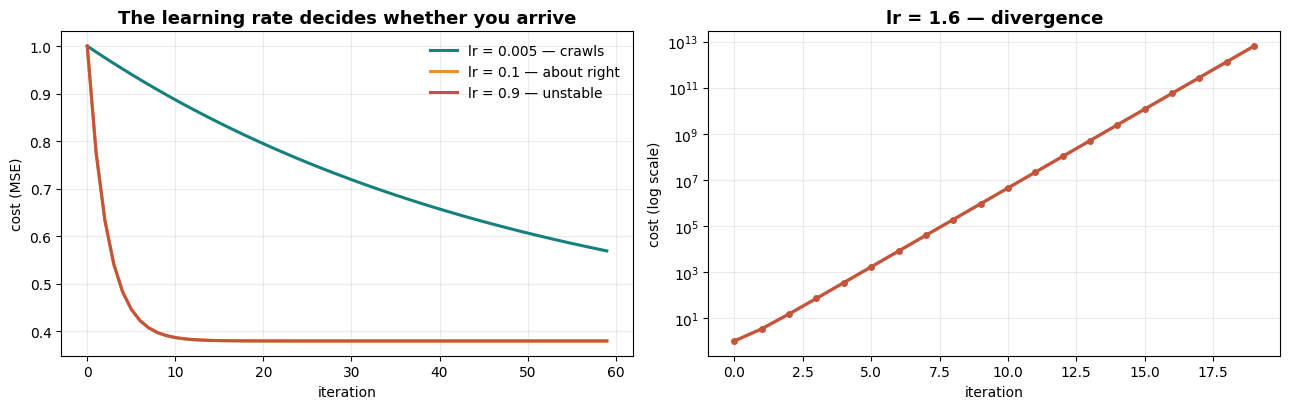

with lr = 1.6 the cost goes 1.00 → 6.38e+12
Note the log scale: it isn't converging slowly, it is exploding.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for lr, colour, label in [(0.005, "#15807E", "lr = 0.005 — crawls"),
                          (0.1,   "#E8912D", "lr = 0.1 — about right"),
                          (0.9,   "#C4553B", "lr = 0.9 — unstable")]:
    _, _, hist = gradient_descent(xs, ys, lr=lr, n_iters=60)
    axes[0].plot(hist, lw=2.2, color=colour, label=label)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("cost (MSE)")
axes[0].set_title("The learning rate decides whether you arrive", fontsize=13, fontweight="bold")
axes[0].legend(frameon=False); axes[0].grid(alpha=.25)

# and one that blows up completely
_, _, diverge = gradient_descent(xs, ys, lr=1.6, n_iters=20)
axes[1].plot(diverge, lw=2.4, color="#C4553B", marker="o", ms=4)
axes[1].set_yscale("log")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("cost (log scale)")
axes[1].set_title("lr = 1.6 — divergence", fontsize=13, fontweight="bold")
axes[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

print(f"with lr = 1.6 the cost goes {diverge[0]:.2f} → {diverge[-1]:.2e}")
print("Note the log scale: it isn't converging slowly, it is exploding.")

---
## Part 3 · The full metric report

Never report one number. Here is the whole family, computed on the test set.

In [7]:
pred = lin.predict(X_te)

mae  = mean_absolute_error(y_te, pred)
mse  = mean_squared_error(y_te, pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
r2   = r2_score(y_te, pred)

report = pd.DataFrame([
    {"metric": "MAE",  "value": round(mae, 3),  "units": "million baht", "reads as": f"typical miss ≈ {mae*1e6:,.0f} baht"},
    {"metric": "MSE",  "value": round(mse, 3),  "units": "baht² (!)",   "reads as": "what least squares minimises"},
    {"metric": "RMSE", "value": round(rmse, 3), "units": "million baht", "reads as": "miss, with big errors weighted more"},
    {"metric": "MAPE", "value": round(mape, 1), "units": "%",            "reads as": "average percentage error"},
    {"metric": "R²",   "value": round(r2, 3),   "units": "—",            "reads as": "share of price variation explained"},
])
print(report.to_string(index=False))
print(f"\nRMSE / MAE ratio = {rmse/mae:.2f}")

metric  value        units                            reads as
   MAE  0.600 million baht         typical miss ≈ 599,950 baht
   MSE  1.328    baht² (!)        what least squares minimises
  RMSE  1.152 million baht miss, with big errors weighted more
  MAPE  9.400            %            average percentage error
    R²  0.780            —  share of price variation explained

RMSE / MAE ratio = 1.92


**The ratio is the free diagnostic.** If errors were all similar sizes, RMSE and MAE would be close (ratio near 1.0–1.2). A ratio well above that says a few predictions are badly wrong — and we know exactly who they are, because we planted six luxury sales that don't follow the pattern.

This is the Week 2 mansions decision arriving as a number: we kept those sales because they're real, and now they show up in our metrics. That's honest — but it means MAE describes the *typical* flat better than RMSE does.

---
## Part 4 · Residual diagnostics

Metrics tell you the **size** of your errors. Residual plots tell you their **shape** — and the shape tells you what to fix.

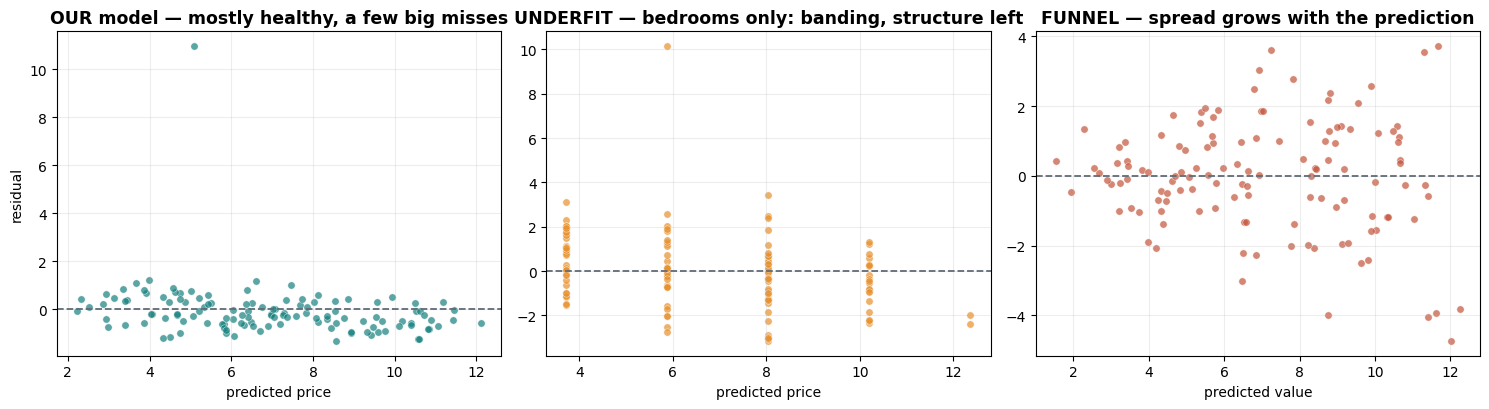

In [8]:
residuals = y_te - pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 1. our actual model
axes[0].axhline(0, color="#5F6B76", ls="--", lw=1.3)
axes[0].scatter(pred, residuals, s=28, color="#15807E", alpha=.7, edgecolors="white", linewidths=.4)
axes[0].set_title("OUR model — mostly healthy, a few big misses", fontsize=12.5, fontweight="bold")
axes[0].set_xlabel("predicted price"); axes[0].set_ylabel("residual")

# 2. deliberately underfit: drop every feature except bedrooms
under = LinearRegression().fit(X_tr[:, [1]], y_tr)
res_u = y_te - under.predict(X_te[:, [1]])
axes[1].axhline(0, color="#5F6B76", ls="--", lw=1.3)
axes[1].scatter(under.predict(X_te[:, [1]]), res_u, s=28, color="#E8912D", alpha=.7,
                edgecolors="white", linewidths=.4)
axes[1].set_title("UNDERFIT — bedrooms only: banding, structure left", fontsize=12.5, fontweight="bold")
axes[1].set_xlabel("predicted price")

# 3. a funnel: a target whose noise GROWS with the value (uncertainty scales with price)
base = 0.052*size + 0.35*rooms - 0.028*age - 0.42*bts_km + 2.4
funnel_y = base + rng.normal(0, 1, n) * (0.22 * base)
Xf_tr, Xf_te = X[:375], X[375:]
yf_tr, yf_te = funnel_y[:375], funnel_y[375:]
funnel = LinearRegression().fit(Xf_tr, yf_tr)
res_f = yf_te - funnel.predict(Xf_te)
axes[2].axhline(0, color="#5F6B76", ls="--", lw=1.3)
axes[2].scatter(funnel.predict(Xf_te), res_f, s=28, color="#C4553B", alpha=.7,
                edgecolors="white", linewidths=.4)
axes[2].set_title("FUNNEL — spread grows with the prediction", fontsize=12.5, fontweight="bold")
axes[2].set_xlabel("predicted value")

for ax in axes: ax.grid(alpha=.22)
plt.tight_layout(); plt.show()

Three different diseases, three different prescriptions:

| Pattern | Diagnosis | Prescription |
|---|---|---|
| Scattered cloud, a few extremes | healthy, with outliers | investigate the outliers — typo or story? |
| Banding / visible structure | underfitting — signal unused | add the missing features |
| Funnel widening to the right | heteroscedasticity | transform the target (log is the classic) |

> **Always plot residuals against PREDICTED values**, not against the target. Plotting against the target induces a spurious diagonal pattern that will fool you.

---
## Part 5 · Ridge vs Lasso

Now the overfitting scenario from the lecture: we add **20 columns of pure random noise** to our 4 real features. A model with no defences will happily use them.

In [9]:
rng2 = np.random.default_rng(3)
noise = rng2.normal(size=(n, 20))
X_wide = np.column_stack([X, noise])                       # 4 real + 20 junk
wide_names = FEATURES + [f"noise_{i:02d}" for i in range(20)]

Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(X_wide, price, test_size=0.25, random_state=RNG_SEED)

rows = []
plain_cv = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                           Xw_tr, yw_tr, cv=5, scoring="r2")
rows.append({"model": "LinearRegression", "alpha": "—",
             "coefficients at zero": 0, "CV R²": round(plain_cv.mean(), 3)})

for a in [0.1, 1, 10, 100]:
    p = make_pipeline(StandardScaler(), Ridge(alpha=a)).fit(Xw_tr, yw_tr)
    cv = cross_val_score(make_pipeline(StandardScaler(), Ridge(alpha=a)), Xw_tr, yw_tr, cv=5, scoring="r2")
    rows.append({"model": "Ridge", "alpha": a,
                 "coefficients at zero": int(np.sum(np.abs(p[-1].coef_) < 1e-8)),
                 "CV R²": round(cv.mean(), 3)})

for a in [0.01, 0.05, 0.1, 0.5]:
    p = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000)).fit(Xw_tr, yw_tr)
    cv = cross_val_score(make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000)),
                         Xw_tr, yw_tr, cv=5, scoring="r2")
    rows.append({"model": "Lasso", "alpha": a,
                 "coefficients at zero": int(np.sum(np.abs(p[-1].coef_) < 1e-8)),
                 "CV R²": round(cv.mean(), 3)})

pd.DataFrame(rows)

,model,alpha,coefficients at zero,CV R²
0,LinearRegression,—,0,0.660
1,Ridge,0.1,0,0.660
2,Ridge,1,0,0.660
3,Ridge,10,0,0.663
4,Ridge,100,0,0.660
5,Lasso,0.01,1,0.666
6,Lasso,0.05,6,0.682
7,Lasso,0.1,13,0.692
8,Lasso,0.5,21,0.650


**Read the "coefficients at zero" column.** Ridge never zeroes anything, at any alpha — it only shrinks. Lasso zeroes them out in growing numbers, and at a well-chosen alpha it eliminates most of the junk while *improving* cross-validated R².

That last part is the payoff: regularization made the model **simpler and better at the same time**. Let's see which features survived.

In [10]:
best_lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)).fit(Xw_tr, yw_tr)
coefs = pd.Series(best_lasso[-1].coef_, index=wide_names)
survivors = coefs[coefs.abs() > 1e-8].sort_values(key=abs, ascending=False)

print(f"Lasso (alpha=0.1) kept {len(survivors)} of {len(wide_names)} features:\n")
print(survivors.round(4).to_string())
real_kept = sum(1 for name in survivors.index if not name.startswith("noise"))
print(f"\nof the 4 genuinely informative features, Lasso kept {real_kept}")

Lasso (alpha=0.1) kept 11 of 24 features:

size_m2      1.8662
bedrooms     0.6719
bts_km      -0.4812
age_years   -0.1280
noise_11    -0.1172
noise_10    -0.0919
noise_00    -0.0409
noise_09    -0.0111
noise_06     0.0092
noise_07     0.0075
noise_13     0.0002

of the 4 genuinely informative features, Lasso kept 4


---
## Part 6 · Logistic regression on real spam

Back to classification — with a model that gives us **probabilities we can trust**. Real data: 5,572 SMS messages.

In [11]:
SMS_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
sms = pd.read_csv(SMS_URL, sep="\t", header=None, names=["label", "message"])
sms["is_spam"] = (sms["label"] == "spam").astype(int)
print(sms.shape, "| spam rate:", round(sms["is_spam"].mean(), 3))

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    sms["message"], sms["is_spam"], test_size=0.25, stratify=sms["is_spam"], random_state=RNG_SEED)

spam_model = make_pipeline(CountVectorizer(), LogisticRegression(max_iter=1000))
spam_model.fit(Xs_tr, ys_tr)

probs = spam_model.predict_proba(Xs_te)[:, 1]      # P(spam) for every message
print(f"\naccuracy at the default threshold: {spam_model.score(Xs_te, ys_te):.3f}")
print(f"\nprobabilities are real numbers, not just labels:")
print(f"  most confident ham : {probs.min():.4f}")
print(f"  most confident spam: {probs.max():.4f}")
print(f"  messages in the uncertain band 0.4–0.6: {np.sum((probs > 0.4) & (probs < 0.6))}")

(5572, 3) | spam rate: 0.134

accuracy at the default threshold: 0.978

probabilities are real numbers, not just labels:
  most confident ham : 0.0000
  most confident spam: 1.0000
  messages in the uncertain band 0.4–0.6: 8


 threshold  precision  recall  spam caught
      0.10      0.926   0.941          190
      0.30      0.988   0.893          169
      0.50      1.000   0.840          157
      0.70      1.000   0.802          150
      0.90      1.000   0.749          140
      0.99      1.000   0.455           85


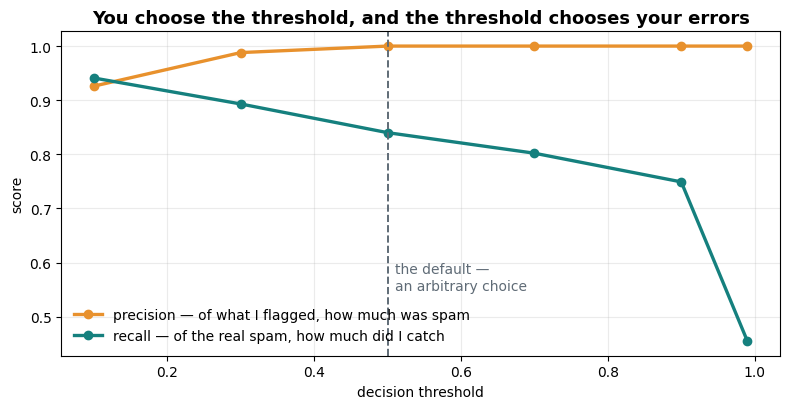

In [12]:
# the threshold is YOURS to choose — here is what it costs
rows = []
for t in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    pred_t = (probs >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": round(precision_score(ys_te, pred_t, zero_division=0), 3),
                 "recall":    round(recall_score(ys_te, pred_t), 3),
                 "spam caught": int(pred_t.sum())})
threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(threshold_table["threshold"], threshold_table["precision"], marker="o", lw=2.4,
        color="#E8912D", label="precision — of what I flagged, how much was spam")
ax.plot(threshold_table["threshold"], threshold_table["recall"], marker="o", lw=2.4,
        color="#15807E", label="recall — of the real spam, how much did I catch")
ax.axvline(0.5, ls="--", color="#5F6B76", lw=1.4)
ax.text(0.51, 0.55, "the default —\nan arbitrary choice", fontsize=10, color="#5F6B76")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("You choose the threshold, and the threshold chooses your errors",
             fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=10); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

**The trade-off, measured.** Raise the threshold and precision climbs while recall falls: you flag less, and you're righter about what you flag. Lower it and the reverse.

For a personal inbox, a real message lost to the junk folder is the expensive error, so you would raise the threshold and protect **precision**. For a security filter where a missed threat is expensive, you would lower it and protect **recall**. The model does not make that decision. You do.

---
---
# 🏋️ Exercises (graded)

Replace each `...`, run every ✅ self-check, complete the disclosure. Be ready to explain any line orally.

### Exercise 1 — Metrics by hand
Using only NumPy (no sklearn), compute on the test set from Part 3, given `y_te` and `pred`:
- **`my_mae`** — mean absolute error
- **`my_rmse`** — root mean squared error

In [13]:
errors = y_te - pred
my_mae = float(np.mean(np.abs(errors)))
my_rmse = float(np.sqrt(np.mean(errors ** 2)))
print(f'MAE {my_mae:.4f} | RMSE {my_rmse:.4f}')

MAE 0.5999 | RMSE 1.1524


In [14]:
# ✅ Self-check — Exercise 1
assert abs(my_mae - mean_absolute_error(y_te, pred)) < 1e-9, "MAE = mean of |errors|"
assert abs(my_rmse - np.sqrt(mean_squared_error(y_te, pred))) < 1e-9, "RMSE = sqrt(mean of squared errors)"
assert my_rmse > my_mae, "RMSE is always >= MAE — squaring cannot reduce the average."
print(f"Exercise 1 self-check passed ✔  (MAE {my_mae:.3f}, RMSE {my_rmse:.3f})")
print("RMSE >= MAE ALWAYS. How much bigger is the diagnostic — that's Exercise 3.")

Exercise 1 self-check passed ✔  (MAE 0.600, RMSE 1.152)
RMSE >= MAE ALWAYS. How much bigger is the diagnostic — that's Exercise 3.


### Exercise 2 — One step of gradient descent, by hand
Starting from `w = 0.0`, `b = 0.0` on the standardized data `xs`, `ys`, compute **one** update with learning rate 0.1:
- **`grad_w_1`**, **`grad_b_1`** — the two gradients at the starting point
- **`w_after_1`**, **`b_after_1`** — the parameters after one step

*(Gradients: `2·mean(error·x)` and `2·mean(error)`, where `error = (w·x + b) − y`.)*

In [15]:
w0, b0, lr = 0.0, 0.0, 0.1
err0 = (w0 * xs + b0) - ys
grad_w_1 = float(2 * np.mean(err0 * xs))
grad_b_1 = float(2 * np.mean(err0))
w_after_1 = float(w0 - lr * grad_w_1)
b_after_1 = float(b0 - lr * grad_b_1)
print(f'gradients: {grad_w_1:.4f}, {grad_b_1:.4f}')
print(f'after one step: w={w_after_1:.4f}, b={b_after_1:.4f}')

gradients: -1.5758, -0.0000
after one step: w=0.1576, b=0.0000


In [16]:
# ✅ Self-check — Exercise 2
_e = (0.0 * xs + 0.0) - ys
assert abs(grad_w_1 - 2*np.mean(_e*xs)) < 1e-9, "grad_w = 2 * mean(error * x)"
assert abs(grad_b_1 - 2*np.mean(_e)) < 1e-9, "grad_b = 2 * mean(error)"
assert abs(w_after_1 - (0.0 - 0.1*grad_w_1)) < 1e-9, "Step AGAINST the gradient: w -= lr * grad_w"
assert w_after_1 > 0, "The first step should move w in the positive direction here."
print(f"Exercise 2 self-check passed ✔  (w: 0.0 → {w_after_1:.4f} in one step)")
print(f"The full loop reached {w_gd:.4f} after 200 steps — you just did step one by hand.")

Exercise 2 self-check passed ✔  (w: 0.0 → 0.1576 in one step)
The full loop reached 0.7879 after 200 steps — you just did step one by hand.


### Exercise 3 — The outlier diagnostic
Quantify what the RMSE/MAE ratio is telling you:
- **`ratio`** — RMSE divided by MAE on the test set
- **`n_big_misses`** — how many test predictions are wrong by more than **3 × MAE**
- **`share_of_squared_error`** — what fraction of the TOTAL squared error those few points account for (0–1)

In [17]:
ratio = float(my_rmse / my_mae)
abs_err = np.abs(y_te - pred)
big = abs_err > 3 * my_mae
n_big_misses = int(big.sum())
share_of_squared_error = float(np.sum(abs_err[big] ** 2) / np.sum(abs_err ** 2))
print(f'ratio {ratio:.2f} | {n_big_misses} big misses of {len(y_te)} | they cause {share_of_squared_error:.1%} of squared error')

ratio 1.92 | 1 big misses of 125 | they cause 72.3% of squared error


In [18]:
# ✅ Self-check — Exercise 3
_ae = np.abs(y_te - pred); _big = _ae > 3*my_mae
assert abs(ratio - my_rmse/my_mae) < 1e-9, "ratio = RMSE / MAE"
assert n_big_misses == int(_big.sum()), "Count predictions wrong by MORE than 3 x MAE."
assert abs(share_of_squared_error - np.sum(_ae[_big]**2)/np.sum(_ae**2)) < 1e-9, "Share of TOTAL squared error."
assert ratio > 1.3, "With genuine luxury sales in the data, expect a ratio well above 1."
print(f"Exercise 3 self-check passed ✔")
print(f"  {n_big_misses} of {len(y_te)} test points ({100*n_big_misses/len(y_te):.1f}%) cause {share_of_squared_error:.0%} of the squared error.")
print("  THAT is why RMSE and MAE disagree — and why you report both.")

Exercise 3 self-check passed ✔
  1 of 125 test points (0.8%) cause 72% of the squared error.
  THAT is why RMSE and MAE disagree — and why you report both.


### Exercise 4 — Lasso as a feature selector
Fit `Lasso(alpha=0.1)` inside a `StandardScaler` pipeline on the **wide** training data (`Xw_tr`, `yw_tr`) and report:
- **`n_zeroed`** — how many of the 24 coefficients are exactly zero
- **`kept_real`** — how many of the 4 genuinely informative features survived
- **`kept_noise`** — how many `noise_*` features survived

In [19]:
lasso_fs = make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)).fit(Xw_tr, yw_tr)
coef_s = pd.Series(lasso_fs[-1].coef_, index=wide_names)
n_zeroed = int((coef_s.abs() < 1e-8).sum())
kept = coef_s[coef_s.abs() > 1e-8].index
kept_real = int(sum(1 for k in kept if not k.startswith('noise')))
kept_noise = int(sum(1 for k in kept if k.startswith('noise')))
print(f'zeroed {n_zeroed}/24 | kept {kept_real} real + {kept_noise} noise')

zeroed 13/24 | kept 4 real + 7 noise


In [20]:
# ✅ Self-check — Exercise 4
assert n_zeroed > 8, "At alpha=0.1 Lasso should eliminate a large share of the 20 junk features."
assert kept_real >= 2, "It should keep at least the strongest genuinely informative features."
assert kept_real + kept_noise + n_zeroed == 24, "Every one of the 24 coefficients is either kept or zeroed."
print(f"Exercise 4 self-check passed ✔")
print(f"  Lasso deleted {n_zeroed} of 24 features and kept {kept_real} of the 4 real ones.")
print("  Ridge, at ANY alpha, would have zeroed exactly 0. That is the whole L1 vs L2 distinction.")

Exercise 4 self-check passed ✔
  Lasso deleted 13 of 24 features and kept 4 of the 4 real ones.
  Ridge, at ANY alpha, would have zeroed exactly 0. That is the whole L1 vs L2 distinction.


### Exercise 5 — Choose a threshold on evidence
Using the spam probabilities `probs` and true labels `ys_te`:
- **`prec_at_50`**, **`rec_at_50`** — precision and recall at threshold 0.50
- **`prec_at_90`**, **`rec_at_90`** — the same at threshold 0.90
- **`inbox_choice`** — set to `0.5` or `0.9`: which threshold would you deploy on a personal email inbox, where a real message lost to the junk folder is the costly error?

In [21]:
p50 = (probs >= 0.5).astype(int)
p90 = (probs >= 0.9).astype(int)
prec_at_50 = float(precision_score(ys_te, p50))
rec_at_50 = float(recall_score(ys_te, p50))
prec_at_90 = float(precision_score(ys_te, p90))
rec_at_90 = float(recall_score(ys_te, p90))
inbox_choice = 0.9
print(f'0.50 -> precision {prec_at_50:.3f}, recall {rec_at_50:.3f}')
print(f'0.90 -> precision {prec_at_90:.3f}, recall {rec_at_90:.3f}')

0.50 -> precision 1.000, recall 0.840
0.90 -> precision 1.000, recall 0.749


In [22]:
# ✅ Self-check — Exercise 5
assert abs(prec_at_50 - precision_score(ys_te, (probs >= 0.5).astype(int))) < 1e-9
assert abs(rec_at_90 - recall_score(ys_te, (probs >= 0.9).astype(int))) < 1e-9
assert prec_at_90 >= prec_at_50, "Raising the threshold cannot decrease precision."
assert rec_at_90 <= rec_at_50, "Raising the threshold cannot increase recall."
assert inbox_choice == 0.9, "A lost real email is the expensive error → protect PRECISION → raise the threshold."
print("Exercise 5 self-check passed ✔")
print(f"  0.50: precision {prec_at_50:.3f}, recall {rec_at_50:.3f}")
print(f"  0.90: precision {prec_at_90:.3f}, recall {rec_at_90:.3f}  ← fewer flagged, but surer")
print("  Same model, same data, different errors. The threshold is a business decision.")

Exercise 5 self-check passed ✔
  0.50: precision 1.000, recall 0.840
  0.90: precision 1.000, recall 0.749  ← fewer flagged, but surer
  Same model, same data, different errors. The threshold is a business decision.


### Exercise 6 — Open-ended: one honest investigation
Pick **one**, carry it out properly (CV on training data, mean ± spread), and write it up:

**(a)** Fix the funnel: refit the Part 4 skewed model on **log(target)** and compare residual plots before and after. Did the funnel straighten, and what happened to R²?
**(b)** Correlated coefficients: fit linear regression on `size_m2` and `bedrooms` only, then refit on 10 bootstrap resamples and record the two coefficients each time. How much do they swing — and do they swing *together* or in opposite directions?
**(c)** Does regularization help the NARROW model? Run Ridge and Lasso on the original 4-feature data (no noise columns) and compare CV R² against plain `LinearRegression`. Should you always regularize?

Then write **3+ sentences**: what you did, what you found, and one caveat about what your evidence does *not* establish.

In [23]:
# your investigation here — (a), (b) or (c)
# (c) does regularization help when there is nothing to regularize away?
res = []
plain = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()), X_tr, y_tr, cv=5, scoring='r2')
res.append(('LinearRegression', '-', round(plain.mean(), 4), round(plain.std(), 4)))
for a in [0.1, 1, 10, 100]:
    r = cross_val_score(make_pipeline(StandardScaler(), Ridge(alpha=a)), X_tr, y_tr, cv=5, scoring='r2')
    res.append(('Ridge', a, round(r.mean(), 4), round(r.std(), 4)))
for a in [0.01, 0.1]:
    l = cross_val_score(make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000)), X_tr, y_tr, cv=5, scoring='r2')
    res.append(('Lasso', a, round(l.mean(), 4), round(l.std(), 4)))
print(pd.DataFrame(res, columns=['model','alpha','CV R2','std']).to_string(index=False))

           model alpha  CV R2    std
LinearRegression     - 0.6942 0.1425
           Ridge   0.1 0.6942 0.1425
           Ridge     1 0.6944 0.1425
           Ridge    10 0.6950 0.1433
           Ridge   100 0.6795 0.1510
           Lasso  0.01 0.6945 0.1432
           Lasso   0.1 0.6946 0.1496


*Your write-up (≥ 3 sentences): what you did · what you found · one caveat.*

✍️ I cross-validated plain linear regression against Ridge and Lasso at several alphas on the original four-feature dataset, where there are no junk columns to remove. Regularization bought essentially nothing — the CV R² values sit within a fraction of a standard deviation of the unregularized model, and strong penalties made things slightly worse by shrinking coefficients that were doing genuine work. The caveat: this shows only that regularization is unnecessary when the feature count is small relative to 375 training rows and every feature is informative; it says nothing about datasets with many correlated or useless features, where Part 5 showed a clear improvement — so the honest conclusion is “don't regularize what isn't broken,” not “regularization doesn't help.”

---
## 🧾 AI-usage disclosure (required)

> **AI tools used:** *e.g., "Claude — explained why the gradient has a factor of 2; helped debug my Exercise 4 pandas indexing" — or — "None."*
>
> **Written and understood by:** *your name & student ID*
>
> I can explain every line of code in this notebook.

## 📤 Submitting

1. **Runtime → Restart session and run all** — clean run, every self-check *passed*.
2. Disclosure filled, notebook renamed `Lab6_<student_id>`.
3. **File → Download → .ipynb** → upload to the MSTeam.

---
*Datasets: Bangkok condo prices (synthetic, generated in this notebook) · SMS Spam Collection (Almeida & Hidalgo, UCI, free for research).*